## KNN (K nearest neighbour)

                                        predicted0      predicted1
    (Specificity)       Actual 0            TN             FP
    (Sensitivity/Recall)Actual 1            FN             TP

Accuracy = TP+TN/Total

In [2]:
from traceback import print_tb

import pandas as pd
from pyasn1_modules.rfc3161 import Accuracy


df = pd.read_csv("C:\\Users\\dapat\\OneDrive\\Dhairya files\\sem4\\Python\\practice\\Python-2_26-main\\Dataset-1\\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
y = df["Outcome"]
x = df.drop("Outcome", axis=1)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [7]:
print(y_pred)

[1 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 1 1
 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0
 1 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 1 0]


In [8]:
from sklearn.metrics import accuracy_score
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

Accuracy Score:  0.7337662337662337


In [26]:
set = {}
for i in range(1,17):
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    set[i] = accuracy_score(y_test, y_pred)
print(set)
set = list(set.values())
#print(set)

{1: 0.720682302771855, 2: 0.767590618336887, 3: 0.757640369580668, 4: 0.7661691542288557, 5: 0.7626154939587776, 6: 0.7732764747690121, 7: 0.7640369580668088, 8: 0.7690120824449183, 9: 0.767590618336887, 10: 0.7775408670931059, 11: 0.7711442786069652, 12: 0.7768301350390903, 13: 0.7725657427149965, 14: 0.775408670931059, 15: 0.7711442786069652, 16: 0.775408670931059}


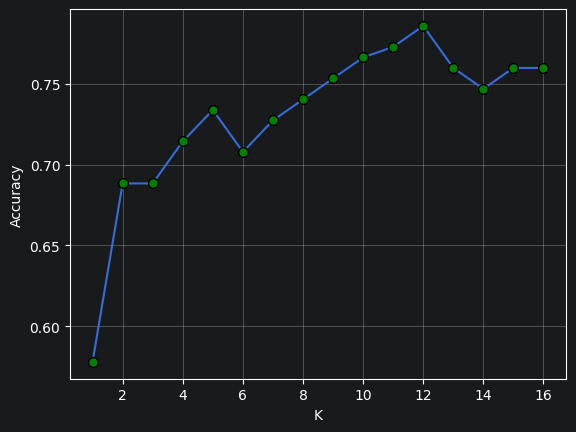

In [10]:
import matplotlib.pyplot as plt
plt.plot(range(1,17),set,ms =7, mec = 'k', mfc = 'g',marker = 'o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(len(y_pred))
print(y_pred)


154
[1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 1 1
 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0
 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 0 0 1 0]


In [12]:
from sklearn.metrics import confusion_matrix
cn = confusion_matrix(y_test, y_pred)
print(cn)

[[90 11]
 [22 31]]


In [13]:
TN,FP,FN,TP =cn[0][0],cn[0][1],cn[1][0],cn[1][1]
Accuracy = (TN + TP)/(TN + FP + FN + TP)
print(Accuracy)

0.7857142857142857


In [14]:
Sensitivity = TP/(TP+FN)
print(Sensitivity)

0.5849056603773585


In [15]:
Specificity = TN/(TN+FP)
print(Specificity)

0.8910891089108911


In [16]:
from sklearn.metrics import recall_score
print(recall_score(y_test, y_pred))

0.5849056603773585


In [17]:
import pandas as pd
df = pd.read_csv("C:\\Users\\dapat\\OneDrive\\Dhairya files\\sem4\\Python\\practice\\Python-2_26-main\\Churn.csv")
df

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   str    
 2   gender            7043 non-null   str    
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   str    
 5   Dependents        7043 non-null   str    
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   str    
 8   MultipleLines     7043 non-null   str    
 9   InternetService   7043 non-null   str    
 10  OnlineSecurity    7043 non-null   str    
 11  OnlineBackup      7043 non-null   str    
 12  DeviceProtection  7043 non-null   str    
 13  TechSupport       7043 non-null   str    
 14  StreamingTV       7043 non-null   str    
 15  StreamingMovies   7043 non-null   str    
 16  Contract          7043 non-null   str    
 17  Paperl

In [19]:
df.dropna(inplace=True,axis=0)
df.drop(columns=['Unnamed: 0','customerID'],inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [20]:
df = pd.get_dummies(df,drop_first=True)
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetService_No  

In [21]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,True,False,True,False,False,True,False
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,True,True,False,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,True,False,False,True,True


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
y = df["Churn_Yes"]
x = df.drop("Churn_Yes",axis=1)
knn = KNeighborsClassifier(n_neighbors=5)
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(y_pred)

[False  True  True ... False False False]


In [23]:
from sklearn.metrics import accuracy_score
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

Accuracy Score:  0.7626154939587776


In [24]:
li = []
for i in range(1,17):
    knn = KNeighborsClassifier(n_neighbors=i)
    x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    li.append(accuracy_score(y_test, y_pred))
print(li)

[0.720682302771855, 0.767590618336887, 0.757640369580668, 0.7661691542288557, 0.7626154939587776, 0.7732764747690121, 0.7640369580668088, 0.7690120824449183, 0.767590618336887, 0.7775408670931059, 0.7711442786069652, 0.7768301350390903, 0.7725657427149965, 0.775408670931059, 0.7711442786069652, 0.775408670931059]


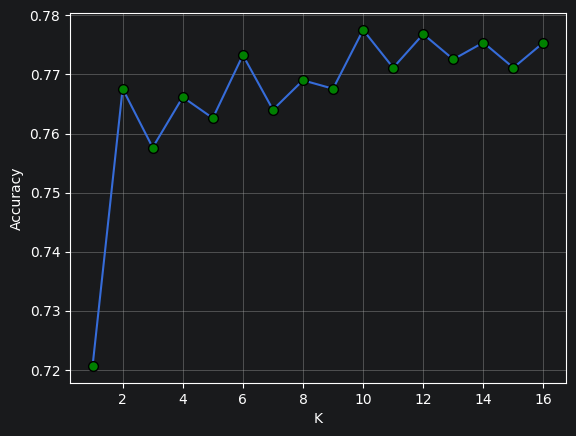

In [25]:
plt.plot(range(1,17),li,ms =7, mec = 'k', mfc = 'g',marker = 'o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [27]:
df = pd.read_csv("churndata_processed.csv")
df

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,...,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
0,0.00,0,0.094118,0,0,1,0,0,0.0,1,...,0,0,1,0,0,0,0,0,0,0
1,0.00,1,0.200000,0,1,0,0,1,0.0,1,...,1,0,0,1,0,0,0,0,0,1
2,0.25,1,0.611765,0,0,0,0,1,0.0,1,...,0,0,0,1,0,0,0,0,1,0
3,0.25,0,0.141176,0,1,1,0,1,0.0,1,...,0,0,0,1,0,0,0,1,0,0
4,0.50,1,0.164706,0,0,0,0,1,0.0,1,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.00,0,0.000000,0,0,0,0,0,1.0,1,...,0,0,0,0,1,0,0,0,0,0
7039,0.25,1,0.282353,1,0,1,1,1,0.5,1,...,0,1,0,0,0,0,0,1,0,0
7040,1.00,1,0.694118,0,1,1,0,1,0.5,1,...,1,0,0,1,0,0,0,0,0,0
7041,0.00,0,0.200000,1,0,0,0,1,0.0,1,...,0,0,1,0,0,0,0,0,0,0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   months                     7043 non-null   float64
 1   multiple                   7043 non-null   int64  
 2   gb_mon                     7043 non-null   float64
 3   security                   7043 non-null   int64  
 4   backup                     7043 non-null   int64  
 5   protection                 7043 non-null   int64  
 6   support                    7043 non-null   int64  
 7   unlimited                  7043 non-null   int64  
 8   contract                   7043 non-null   float64
 9   paperless                  7043 non-null   int64  
 10  monthly                    7043 non-null   float64
 11  satisfaction               7043 non-null   float64
 12  churn_value                7043 non-null   int64  
 13  payment_Credit Card        7043 non-null   int64  
 14  pay

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score
y = df["churn_value"]
x = df.drop("churn_value",axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print("accuracy score: ", accuracy_score(y_test, y_pred))

accuracy score:  0.8892831795599716


In [37]:
li =[]
for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    li.append(accuracy_score(y_test, y_pred))


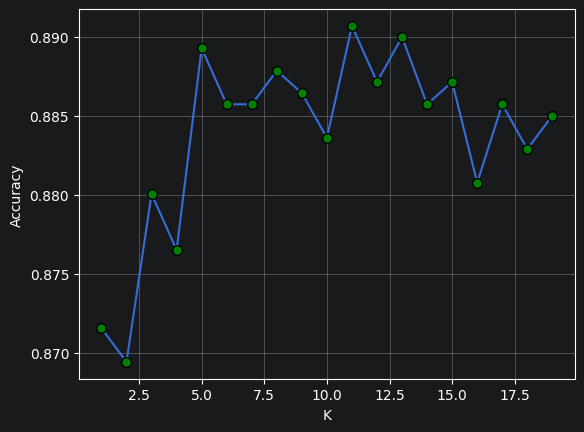

In [38]:
from matplotlib import pyplot as plt
plt.plot(range(1,20),li,ms =7, mec = 'k', mfc = 'g',marker = 'o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [50]:
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print("accuracy score: ", accuracy_score(y_test, y_pred))
print("recall_score: ", recall_score(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cn = confusion_matrix(y_test, y_pred)
Specificity = TN/(TN+FP)
print("Specificity:",Specificity)

accuracy score:  0.8871540099361249
recall_score:  0.7286432160804021
Specificity: 0.8910891089108911


In [51]:
from sklearn.model_selection import GridSearchCV
params = {'n_neighbors' : range(1,21)}
grid = GridSearchCV(KNeighborsClassifier(),param_grid=params,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

{'n_neighbors': 15}

In [53]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1011
           1       0.85      0.73      0.78       398

    accuracy                           0.89      1409
   macro avg       0.87      0.84      0.85      1409
weighted avg       0.89      0.89      0.88      1409



In [55]:
print(y_test.shape)

(1409,)


In [57]:
df = pd.read_csv("glass.csv")
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [63]:
df[df.duplicated()]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [64]:
df.drop_duplicates(inplace=True)

In [65]:
df.info()

<class 'pandas.DataFrame'>
Index: 213 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      213 non-null    float64
 1   Na      213 non-null    float64
 2   Mg      213 non-null    float64
 3   Al      213 non-null    float64
 4   Si      213 non-null    float64
 5   K       213 non-null    float64
 6   Ca      213 non-null    float64
 7   Ba      213 non-null    float64
 8   Fe      213 non-null    float64
 9   Type    213 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 18.3 KB


In [67]:
df.duplicated().sum()

np.int64(0)